# 05 — LUNA16 ResNet50 (random init) — transfer learning ablation

Identical pipeline to notebook 04 except `pretrained=False`. Pairwise Wilcoxon on per-fold AUC against the pretrained run (in notebook 06) answers research question 1.3 from the diploma.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import yaml
from torchvision import transforms

from utils.seed import set_seed
from utils.models import build_resnet50
from utils.data_luna16 import SlicesDataset
from utils.training import train_dl_cv, save_fold_results
from utils.metrics import aggregate_folds
from utils.stats import format_results_table

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)
set_seed(cfg['seed'])

cache_dir = Path('..') / cfg['data']['cache_dir']
slices = np.load(cache_dir / 'slices_2d.npy')
_labels_df = pd.read_csv(cache_dir / 'labels.csv')
labels = _labels_df['label'].to_numpy().astype(int)
groups = _labels_df['seriesuid'].to_numpy()  # GroupKFold by CT scan

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])
eval_tf = None

dataset = SlicesDataset(slices, labels, transform=eval_tf)
print('slices', slices.shape, 'pos rate:', labels.mean())

slices (448, 224, 224) pos rate: 0.25


In [2]:
def model_fn():
    return build_resnet50(pretrained=False, num_classes=1)

results_dir = Path('..') / cfg['paths']['results']
results_dir.mkdir(parents=True, exist_ok=True)

folds = train_dl_cv(
    dataset=dataset,
    model_fn=model_fn,
    labels=labels,
    n_splits=cfg['cv']['n_splits'],
    seed=cfg['seed'],
    epochs=cfg['dl']['epochs'],
    batch_size=cfg['dl']['batch_size'],
    lr=cfg['dl']['lr'],
    weight_decay=cfg['dl']['weight_decay'],
    patience=cfg['dl']['patience'],
    num_workers=cfg['dl']['num_workers'],
    device='auto',
    augment_train=train_tf,
    augment_eval=eval_tf,
    groups=groups,
    verbose=True,
)

save_fold_results(folds, results_dir / 'luna16_ResNet50_scratch.json')
agg = aggregate_folds([f.metrics_calibrated for f in folds])
format_results_table({'ResNet50_scratch': agg})

[fold 0] train=356 test=92 pos_train=89 pos_test=23
  epoch  1/50 loss=1.1174 val_auc=0.5236
  epoch  2/50 loss=1.0660 val_auc=0.5110
  epoch  3/50 loss=1.0288 val_auc=0.5425
  epoch  4/50 loss=1.0136 val_auc=0.5778


Python(94793) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94803) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94817) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94819) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94966) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94979) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94985) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94988) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  epoch  5/50 loss=1.0601 val_auc=0.5671


Python(95032) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95055) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95065) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95182) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95211) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95233) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  epoch  6/50 loss=1.0075 val_auc=0.5784


...

Python(14101) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14114) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14129) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14264) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14294) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14332) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  epoch 18/50 loss=0.6897 val_auc=0.6006
  early stop at epoch 18 (patience=7)


Python(14384) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14397) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14412) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14422) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14502) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14513) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14528) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14543) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[fold 4] AUC=0.6949 thr=0.802 BalAcc(cal)=0.629


,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,auc_roc,pr_auc
model,,,,,,,,
ResNet50_scratch,0.652 ± 0.097,0.598 ± 0.084,0.670 ± 0.143,0.402 ± 0.118,0.470 ± 0.071,0.634 ± 0.059,0.705 ± 0.107,0.460 ± 0.130


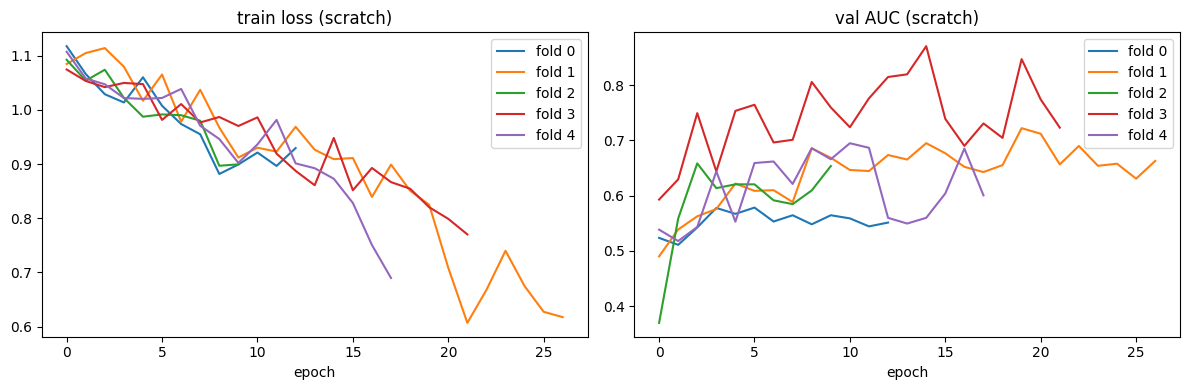

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for f in folds:
    if f.train_history is None:
        continue
    axes[0].plot(f.train_history['loss'], label=f'fold {f.fold}')
    axes[1].plot(f.train_history['auc'], label=f'fold {f.fold}')
axes[0].set_title('train loss (scratch)'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('val AUC (scratch)'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()